Step 1: Import Libraries




In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

Task 1 : Data Preparation


Load Dataset

In [29]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

df = X.copy()
df["Target"] = y

df.head()
df.info()
df.shape
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

np.int64(0)

Feature Scaling



In [30]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Task 2 : Train-Test Split

In [31]:
X_train,X_test,y_train,y_test=train_test_split(
X_scaled,
y,
test_size=0.2,
random_state=42)

In [32]:
X_train70,X_test70,y_train70,y_test70=train_test_split(
X_scaled,
y,
test_size=0.3,
random_state=42)

In [33]:
X_train90,X_test90,y_train90,y_test90=train_test_split(
X_scaled,
y,
test_size=0.1,
random_state=42)

Comparison of Train-Test Splits

- 80:20 provides a balanced amount of training and testing data and generally produces stable results.
- 70:30 offers a larger test set but slightly less training data.
- 90:10 provides maximum training data but a very small testing set, making evaluation less reliable.
- Overall, the 80:20 split provides the best balance between model learning and generalization.

Task 3 : Heuristic K Selection

In [34]:
n = len(X_train)

k = int(np.sqrt(n))

print(k)

21


In [35]:
knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train,y_train)

prediction = knn.predict(X_test)

accuracy_score(y_test,prediction)

0.9473684210526315

In [36]:
k_values = list(range(k-5,k+6))

accuracy=[]

for i in k_values:

    model = KNeighborsClassifier(n_neighbors=i)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    accuracy.append(accuracy_score(y_test,pred))

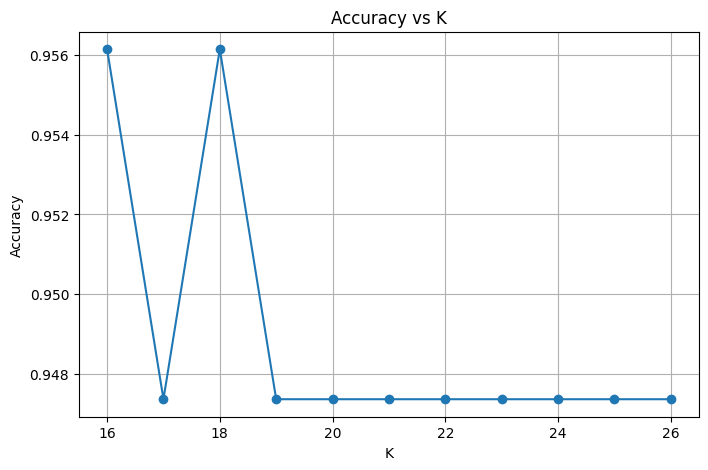

In [37]:
plt.figure(figsize=(8,5))

plt.plot(k_values,accuracy,marker='o')

plt.xlabel("K")

plt.ylabel("Accuracy")

plt.title("Accuracy vs K")

plt.grid()

plt.show()

In [38]:
X2 = X_scaled[:,0:2]

X_train,X_test,y_train,y_test=train_test_split(
X2,y,test_size=0.2,random_state=42)

In [39]:
from matplotlib.colors import ListedColormap

def plot_boundary(k):

    model=KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    x_min,x_max=X_train[:,0].min()-1,X_train[:,0].max()+1
    y_min,y_max=X_train[:,1].min()-1,X_train[:,1].max()+1

    xx,yy=np.meshgrid(
        np.arange(x_min,x_max,0.02),
        np.arange(y_min,y_max,0.02)
    )

    Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
    Z=Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))

    plt.contourf(xx,yy,Z,alpha=0.3)

    plt.scatter(X_train[:,0],X_train[:,1],c=y_train)

    plt.title(f"K={k}")

    plt.show()

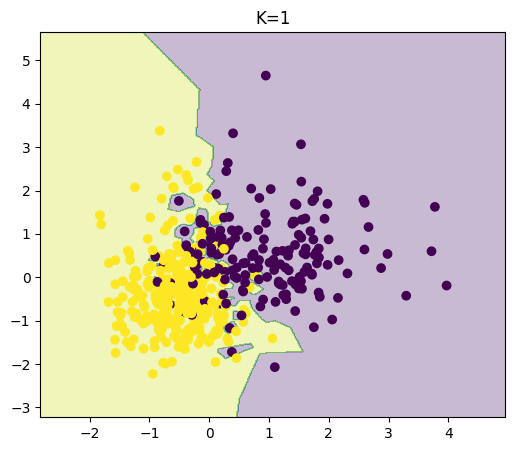

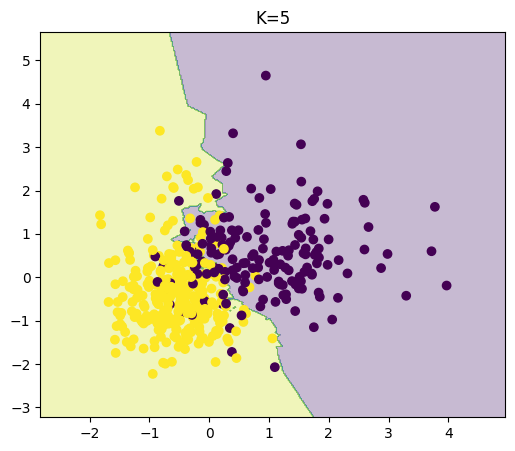

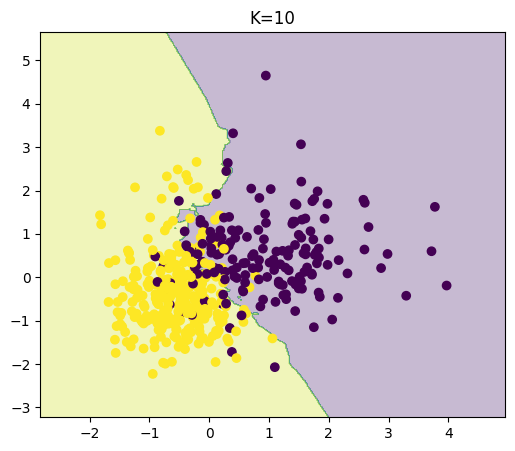

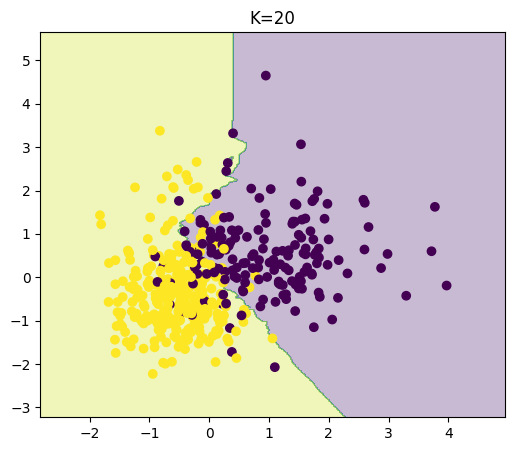

In [40]:
plot_boundary(1)
plot_boundary(5)
plot_boundary(10)
plot_boundary(20)

Task 3.3: Distance Metrics Used in KNN



In [53]:
best_k=k_values[np.argmax(mean_accuracy)]

print(best_k)

9


In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn_euclidean = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_euclidean.fit(X_train, y_train)
euclidean_accuracy = knn_euclidean.score(X_test, y_test)

knn_manhattan = KNeighborsClassifier(n_neighbors=best_k, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
manhattan_accuracy = knn_manhattan.score(X_test, y_test)

print("Euclidean Accuracy :", round(euclidean_accuracy, 4))
print("Manhattan Accuracy :", round(manhattan_accuracy, 4))

Euclidean Accuracy : 0.9211
Manhattan Accuracy : 0.9211


Task 4 : Cross Validation

In [42]:
k_values=range(1,31)

mean_accuracy=[]

for i in k_values:

    model=KNeighborsClassifier(n_neighbors=i)

    score=cross_val_score(model,X_scaled,y,cv=5)

    mean_accuracy.append(score.mean())

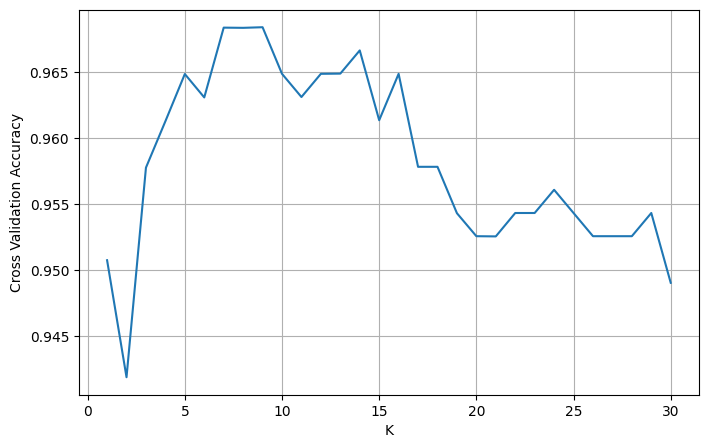

In [43]:
plt.figure(figsize=(8,5))

plt.plot(k_values,mean_accuracy)

plt.xlabel("K")

plt.ylabel("Cross Validation Accuracy")

plt.grid()

plt.show()

In [44]:
best_k=k_values[np.argmax(mean_accuracy)]

print(best_k)

9


Cross Validation Analysis

Cross-validation provides a more reliable estimate of model performance because every sample is used for both training and testing across different folds. The optimal K selected using cross-validation is more robust than selecting K from a single train-test split.

Task 5 : Evaluation Metrics

In [45]:
model=KNeighborsClassifier(n_neighbors=best_k)

model.fit(X_train,y_train)

prediction=model.predict(X_test)

In [46]:
accuracy_score(y_test,prediction)

0.9210526315789473

In [47]:
precision_score(y_test,prediction)

0.9428571428571428

In [48]:
recall_score(y_test,prediction)

0.9295774647887324

In [49]:
from sklearn.metrics import f1_score

f1_score(y_test, prediction)

0.9361702127659575

[[39  4]
 [ 5 66]]


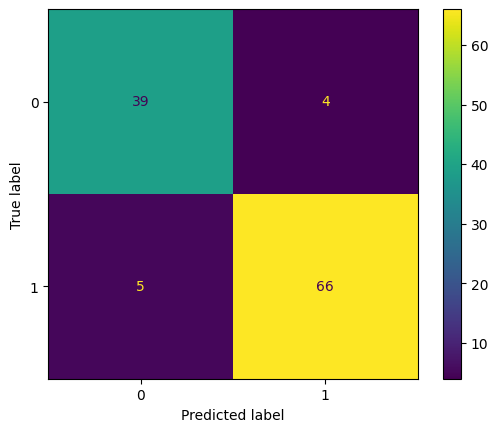

In [50]:
cm=confusion_matrix(y_test,prediction)

print(cm)

ConfusionMatrixDisplay(cm).plot()

plt.show()

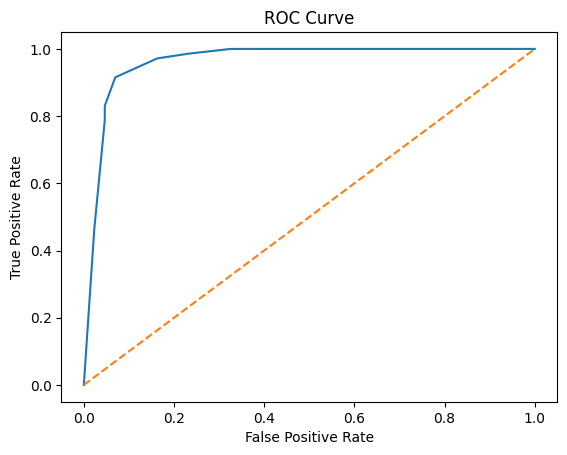

In [51]:
prob=model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,prob)

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [52]:
roc_auc_score(y_test,prob)

np.float64(0.9631509990173599)

ROC-AUC Interpretation

The ROC curve shows the trade-off between the True Positive Rate and False Positive Rate. A higher AUC indicates better discrimination between benign and malignant tumors. Since medical diagnosis requires minimizing false negatives, ROC-AUC is an important evaluation metric.

Task 6 : Comparison with Lab 3


Regression


1.   MAE measures average prediction error
2.   MSE squares the errors
1.   RMSE gives error magnitude
2.   R² measures goodness of fit
1.   Used for continuous outputs

Classification

1.   Accuracy measures correct predictions
1.   Precision measures positive prediction quality
1.  Recall measures ability to detect positives
2.  F1 balances Precision and Recall
2.   Used for categorical outputs














Task 7 : Analytical Answers

1. Why is KNN called a lazy learner?

Because it does not build a model during training and stores all training data. Computation happens only during prediction.

2. Why feature scaling?

Distance calculations are affected by feature magnitudes. Scaling ensures equal contribution from all features.

3. Explain heuristic K selection.

The heuristic selects K=
n
	​

, where n is the number of training samples. It provides a balanced initial value.

4. Why Cross Validation?

It evaluates the model on multiple train-test splits, reducing bias and providing more reliable performance estimates.

5. How does K affect Bias-Variance?

Small K → Low bias, high variance (overfitting)
Large K → High bias, low variance (underfitting)

6. Why is Recall important in cancer prediction?

Recall minimizes false negatives, ensuring cancer cases are not missed.

7. Limitation of large K?

Large K can oversmooth decision boundaries, leading to underfitting and reduced sensitivity to local patterns.

8. What is Euclidean Distance?

Euclidean distance is the straight-line distance between two points in a feature space. It is the default distance metric used in KNN to measure how similar two data points are.

9. What is Manhattan Distance?

Manhattan distance is the sum of the absolute differences between the coordinates of two points. It measures distance by moving along horizontal and vertical paths, like traveling through city streets.

Inference

Regression metrics such as MAE, MSE, RMSE and R² evaluate prediction errors for continuous values.

Classification metrics evaluate how correctly a model predicts class labels.

In healthcare, accuracy alone is insufficient because predicting a cancer patient as healthy can have severe consequences. Recall is therefore more important as it minimizes false negatives. ROC-AUC evaluates the model's ability to distinguish between classes across different thresholds.

Overall, regression focuses on minimizing prediction error, whereas classification focuses on making correct decisions.